Setup working
Libraries ready ✓
200
Page size: 492510 characters


/tmp/ipykernel_10811/1389821884.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Number of tables found: 19
    0                                                  1
0 NaN  Abbreviations key #=Jumper GM=Games played KI=...
Table 0: (1, 2) columns: [0, 1]

Table 1: (36, 28) columns: [('Adelaide [Players Game by Game][Team Game by Game]', '#'), ('Adelaide [Players Game by Game][Team Game by Game]', 'Player'), ('Adelaide [Players Game by Game][Team Game by Game]', 'GM'), ('Adelaide [Players Game by Game][Team Game by Game]', 'KI'), ('Adelaide [Players Game by Game][Team Game by Game]', 'MK')]

Table 2: (36, 28) columns: [('Brisbane Lions [Players Game by Game][Team Game by Game]', '#'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'Player'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'GM'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'KI'), ('Brisbane Lions [Players Game by Game][Team Game by Game]', 'MK')]

Table 3: (39, 28) columns: [('Carlton [Players Game by Game][Team Game by Game]', '#'), ('Carlton [Players Game 

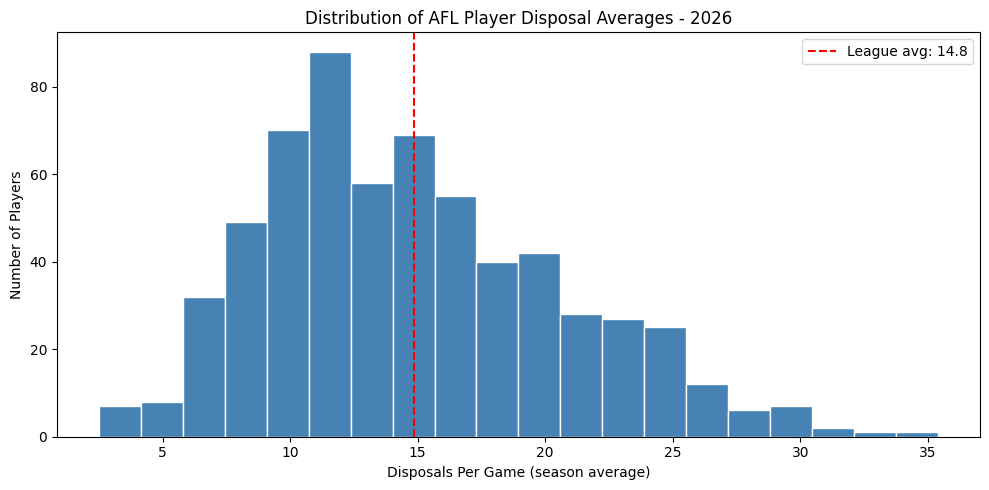

League average disposals per game: 14.8
Highest: Daicos, Nick - 35.4
Lowest: Ramm, Harrison - 2.5
627 players exported
            player                    team position
0     Daicos, Nick             Collingwood         
1    Smith, Bailey                 Geelong         
2  Oliver, Clayton  Greater Western Sydney         
3   Sheezel, Harry         North Melbourne         
4    Neale, Lachie          Brisbane Lions         


FileNotFoundError: [Errno 2] No such file or directory: 'complete_player_positions .xlsx'

In [3]:
import pandas as pd
print("Setup working")

import requests
import pandas as pd
print("Libraries ready ✓")

url = "https://afltables.com/afl/stats/2026.html"
response = requests.get(url, headers={"User-Agent": "afl-disposal-model-learning-project"})
print(response.status_code)
print(f"Page size: {len(response.text)} characters")

# pandas can read HTML tables directly from a page
tables = pd.read_html(response.text)
print(f"Number of tables found: {len(tables)}")
print(tables[0].head())  # preview the first table

for i, table in enumerate(tables):
    print(f"Table {i}: {table.shape} columns: {list(table.columns[:5])}")
    print()

all_players = []

for i in range(1, 19):
    table = tables[i].copy()

    # get team name from the top level of the multi-index column
    team_name = tables[i].columns[0][0].replace(" [Players Game by Game][Team Game by Game]", "")

    # flatten columns to just the stat abbreviation (bottom level)
    table.columns = [col[1] for col in tables[i].columns]

    # add team column
    table['team'] = team_name

    all_players.append(table)

# stack them on top of each other
df = pd.concat(all_players, ignore_index=True)

print(df.shape)
print(df.columns.tolist())
print(df.head())

# keep only the columns we care about
df_clean = df[['Player', 'team', 'GM', 'KI', 'HB', 'DI']].copy()

# rename for clarity
df_clean.columns = ['player', 'team', 'games', 'kicks', 'handballs', 'disposals']

# convert to numbers (some might be strings)
for col in ['games', 'kicks', 'handballs', 'disposals']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# drop rows with no data (substitute/rookie listed players who played 0 games)
df_clean = df_clean.dropna()
df_clean = df_clean[df_clean['games'] > 0]

# calculate per game averages
df_clean['disposals_per_game'] = (df_clean['disposals'] / df_clean['games']).round(1)
df_clean['kicks_per_game'] = (df_clean['kicks'] / df_clean['games']).round(1)
df_clean['handballs_per_game'] = (df_clean['handballs'] / df_clean['games']).round(1)

# sort by disposals per game
df_clean = df_clean.sort_values('disposals_per_game', ascending=False).reset_index(drop=True)

print(df_clean.shape)
print(df_clean.head(10))

# the baseline prediction for each player is simply their season average
df_clean['baseline_prediction'] = df_clean['disposals_per_game']

# to evaluate it properly we need to simulate:
# "if we predicted their season average, how wrong were we per game?"
# we can approximate this using each player's kicks vs handballs variability
# but first - let's just look at the distribution of averages

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_clean['disposals_per_game'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Disposals Per Game (season average)')
plt.ylabel('Number of Players')
plt.title('Distribution of AFL Player Disposal Averages - 2026')
plt.axvline(df_clean['disposals_per_game'].mean(), color='red', linestyle='--', label=f"League avg: {df_clean['disposals_per_game'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"League average disposals per game: {df_clean['disposals_per_game'].mean():.1f}")
print(f"Highest: {df_clean.iloc[0]['player']} - {df_clean.iloc[0]['disposals_per_game']}")
print(f"Lowest: {df_clean.iloc[-1]['player']} - {df_clean.iloc[-1]['disposals_per_game']}")

player_list = df_clean[['player', 'team']].copy()
player_list['position'] = ''  # empty column for you to fill in

player_list.to_csv('players_to_classify.csv', index=False)
print(f"{len(player_list)} players exported")
print(player_list.head())


In [10]:

import pandas as pd

# load your positions file
positions = pd.read_excel('complete player positions .xlsx')
positions.columns = ['player', 'team', 'position']

# standardise to FNF taxonomy
position_map = {
    'contested inside mid': 'MID-INC',
    'uncontested inside mid': 'MID-INU',
    'outside mid': 'MID-OUT',
    'forward mid': 'MID-FWD',
    'mid forward': 'MID-FWD',
    'defensive users': 'DEF-USER',
    'defensive user': 'DEF-USER',
    'general defender': 'DEF-GEN',
    'key defender': 'DEF-KEY',
    'general forward': 'FWD-GEN',
    'key forward': 'FWD-KEY',
    'small forward': 'FWD-SML',
    'winger': 'WING',
    'ruck-tap': 'RUC-TAP',
    'ruck-forward': 'RUC-FWD',
    'forward ruck': 'RUC-FWD',
    'mobile ruck': 'RUC-MOB',
    'main tagger': 'MID-TAG',
}

# clean and map
positions['position'] = positions['position'].str.strip().str.lower().map(position_map)

# drop blanks
positions = positions.dropna(subset=['position'])

print(positions['position'].value_counts())
print(f"\nTotal players with positions: {len(positions)}")
print(positions.head(10))


position
DEF-GEN     73
DEF-KEY     72
WING        71
FWD-KEY     60
FWD-SML     48
FWD-GEN     46
MID-OUT     40
MID-INC     36
DEF-USER    24
MID-INU     24
RUC-TAP     20
RUC-FWD     19
MID-FWD     14
MID-TAG      1
Name: count, dtype: int64

Total players with positions: 548
             player      team position
0       Laird, Rory  Adelaide  DEF-GEN
1    Dawson, Jordan  Adelaide  MID-INU
2     Worrell, Josh  Adelaide  DEF-KEY
3        Berry, Sam  Adelaide  MID-INC
4       Keane, Mark  Adelaide  DEF-KEY
5  Hall-Kahan, Hugo  Adelaide  DEF-GEN
6   Peatling, James  Adelaide  MID-INC
7     Rankine, Izak  Adelaide  MID-INU
8     Rachele, Josh  Adelaide  MID-FWD
9     Cook, Brayden  Adelaide     WING


In [11]:
# merge positions onto the main dataframe
df_model = df_clean.merge(positions, on=['player', 'team'], how='inner')

print(f"Players with both disposal data and positions: {len(df_model)}")
print(f"Teams represented: {df_model['team'].nunique()}")
print(df_model[['player', 'team', 'position', 'disposals_per_game']].head(10))

Players with both disposal data and positions: 548
Teams represented: 18
                     player                    team  position  \
0              Daicos, Nick             Collingwood   MID-INU   
1             Smith, Bailey                 Geelong   MID-INU   
2           Oliver, Clayton  Greater Western Sydney   MID-INC   
3            Sheezel, Harry         North Melbourne   MID-INU   
4             Neale, Lachie          Brisbane Lions   MID-INC   
5           Roberts, Archie                Essendon   MID-OUT   
6               Ash, Lachie  Greater Western Sydney  DEF-USER   
7              Butters, Zak           Port Adelaide   MID-INU   
8  Wanganeen-Milera, Nasiah                St Kilda   MID-INU   
9               Holmes, Max                 Geelong   MID-OUT   

   disposals_per_game  
0                35.4  
1                32.3  
2                31.5  
3                30.5  
4                30.4  
5                30.1  
6                29.9  
7                29

In [15]:
from io import StringIO
from bs4 import BeautifulSoup
import time

# get the 2026 season index page
season_url = "https://afltables.com/afl/seas/2026.html"
response = requests.get(season_url, headers={"User-Agent": "afl-disposal-model-learning-project"})
print(response.status_code)

soup = BeautifulSoup(response.text, 'html.parser')

game_links = []
for a in soup.find_all('a', href=True):
    href = a['href']
    # fix relative paths
    if 'stats/games/2026/' in href:
        # handle both absolute and relative hrefs
        if href.startswith('http'):
            full_url = href
        elif href.startswith('/'):
            full_url = 'https://afltables.com' + href
        else:
            # relative like ../../stats/games/2026/...
            full_url = 'https://afltables.com/afl/' + href.lstrip('./')

        # clean up any double slashes
        full_url = full_url.replace('afltables.com//', 'afltables.com/')

        if full_url not in game_links:
            game_links.append(full_url)

print(f"Found {len(game_links)} game URLs")
print(game_links[:5])

200
Found 128 game URLs
['https://afltables.com/afl/stats/games/2026/031620260305.html', 'https://afltables.com/afl/stats/games/2026/092020260306.html', 'https://afltables.com/afl/stats/games/2026/102120260307.html', 'https://afltables.com/afl/stats/games/2026/071920260307.html', 'https://afltables.com/afl/stats/games/2026/041520260308.html']


In [17]:
from bs4 import BeautifulSoup
import time

all_game_stats = []

for i, url in enumerate(game_links):
    try:
        response = requests.get(url, headers={"User-Agent": "afl-disposal-model-learning-project"})
        soup = BeautifulSoup(response.text, 'html.parser')

        # get game_id from URL
        game_id = url.split('/')[-1].replace('.html', '')

        # extract team names from the stat table headers
        tables = pd.read_html(StringIO(response.text))

        # find headers that contain "Match Statistics"
        team_names = []
        for tag in soup.find_all(['h2', 'h3', 'caption', 'th']):
            text = tag.get_text(strip=True)
            if 'Match Statistics' in text:
                team = text.replace('Match Statistics', '').strip()
                if team:
                    team_names.append(team)

        # fallback: get from page title
        if len(team_names) < 2:
            title = soup.find('title')
            if title:
                # title like "Sydney v Collingwood - Fri, 15-May-2026"
                title_text = title.text.split('-')[0].strip()
                if ' v ' in title_text:
                    parts = title_text.split(' v ')
                    team_names = [parts[0].strip(), parts[1].strip()]

        team_idx = 0
        for table in tables:
            # check if this is a player stats table
            cols = [str(c) for c in table.columns]
            if 'DI' not in cols and not any('DI' in str(c) for c in table.columns):
                continue
            if isinstance(table.columns, pd.MultiIndex):
                table.columns = [col[-1] for col in table.columns]
            if 'DI' not in table.columns:
                continue
            if 'Player' not in table.columns:
                continue

            team = team_names[team_idx] if team_idx < len(team_names) else 'Unknown'
            opponent = team_names[1 - team_idx] if len(team_names) == 2 else 'Unknown'

            for _, row in table.iterrows():
                player = str(row.get('Player', '')).strip()
                if not player or player == 'nan' or player == 'Player':
                    continue
                all_game_stats.append({
                    'player': player,
                    'team': team,
                    'opponent': opponent,
                    'game_id': game_id,
                    'disposals': pd.to_numeric(row.get('DI'), errors='coerce'),
                    'kicks': pd.to_numeric(row.get('KI'), errors='coerce'),
                    'handballs': pd.to_numeric(row.get('HB'), errors='coerce'),
                })
            team_idx += 1

        if (i + 1) % 10 == 0:
            print(f"Scraped {i + 1}/{len(game_links)} games...")

        time.sleep(0.5)

    except Exception as e:
        print(f"Error on {url}: {e}")
        continue

df_games = pd.DataFrame(all_game_stats)
print(f"\nDone! Shape: {df_games.shape}")
print(df_games[['player','team','opponent','disposals']].head(10))

Scraped 10/128 games...
Scraped 20/128 games...
Scraped 30/128 games...
Scraped 40/128 games...
Scraped 50/128 games...
Scraped 60/128 games...
Scraped 70/128 games...
Scraped 80/128 games...
Scraped 90/128 games...
Scraped 100/128 games...
Scraped 110/128 games...
Scraped 120/128 games...

Done! Shape: (6626, 7)
            player                            team  \
0    Amartey, Joel  Sydney  [Season][Game by Game]   
1      Bice, Riley  Sydney  [Season][Game by Game]   
2     Blakey, Nick  Sydney  [Season][Game by Game]   
3  Curnow, Charlie  Sydney  [Season][Game by Game]   
4   Grundy, Brodie  Sydney  [Season][Game by Game]   
5    Gulden, Errol  Sydney  [Season][Game by Game]   
6    Heeney, Isaac  Sydney  [Season][Game by Game]   
7    Jordon, James  Sydney  [Season][Game by Game]   
8      Lloyd, Jake  Sydney  [Season][Game by Game]   
9    McCartin, Tom  Sydney  [Season][Game by Game]   

                          opponent  disposals  
0  Carlton  [Season][Game by Game]        

In [18]:
# clean the [Season][Game by Game] junk from team names
df_games['team'] = df_games['team'].str.replace(r'\[.*?\]', '', regex=True).str.strip()
df_games['opponent'] = df_games['opponent'].str.replace(r'\[.*?\]', '', regex=True).str.strip()

# check what we've got
print(df_games['team'].value_counts())
print("\nSample of different games:")
print(df_games[['player','team','opponent','disposals']].drop_duplicates('team').head(10))
print(f"\nUnique opponents: {df_games['opponent'].nunique()}")
print(f"Unique teams: {df_games['team'].nunique()}")

team
Geelong                   390
Melbourne                 389
St Kilda                  388
Western Bulldogs          388
Brisbane Lions            364
Carlton                   363
West Coast                363
Gold Coast                363
Richmond                  363
North Melbourne           363
Essendon                  362
Collingwood               362
Greater Western Sydney    362
Hawthorn                  362
Fremantle                 362
Adelaide                  361
Port Adelaide             361
Sydney                    360
Name: count, dtype: int64

Sample of different games:
             player                    team                opponent  disposals
0     Amartey, Joel                  Sydney                 Carlton        7.0
25   Ainsworth, Ben                 Carlton                  Sydney       14.0
51     Adams, Oscar              Gold Coast                 Geelong       12.0
76      Atkins, Tom                 Geelong              Gold Coast       26.0
102   

In [19]:
# merge game-by-game data with positions
df_merged = df_games.merge(positions[['player', 'position']], on='player', how='inner')

print(f"Rows after merge: {len(df_merged)}")
print(f"Unique players: {df_merged['player'].nunique()}")

# calculate each player's season average disposals
player_avg = df_merged.groupby('player')['disposals'].mean().rename('player_avg')
df_merged = df_merged.merge(player_avg, on='player')

# calculate edge = actual disposals - player's season average
df_merged['edge'] = df_merged['disposals'] - df_merged['player_avg']

# now calculate position-vs-opponent edge matrix
# for each position + opponent combo, average the edge scores
edge_matrix = df_merged.groupby(['opponent', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index()

print(edge_matrix.head(20))

Rows after merge: 5312
Unique players: 548
          opponent  position  edge_score  sample_size
0         Adelaide   DEF-GEN       -0.11           40
1         Adelaide   DEF-KEY        0.19           33
2         Adelaide  DEF-USER       -2.57           14
3         Adelaide   FWD-GEN       -0.83           17
4         Adelaide   FWD-KEY       -0.34           31
5         Adelaide   FWD-SML       -1.24           22
6         Adelaide   MID-FWD       -2.18            7
7         Adelaide   MID-INC        1.90           22
8         Adelaide   MID-INU        0.11           15
9         Adelaide   MID-OUT       -1.59           26
10        Adelaide   RUC-FWD        0.28            8
11        Adelaide   RUC-TAP        0.61            9
12        Adelaide      WING       -0.90           30
13  Brisbane Lions   DEF-GEN       -0.23           39
14  Brisbane Lions   DEF-KEY       -1.76           37
15  Brisbane Lions  DEF-USER       -0.46           15
16  Brisbane Lions   FWD-GEN        0.1

In [22]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

teams = sorted(edge_matrix['opponent'].unique().tolist())

team1_dropdown = widgets.Dropdown(options=teams, value='Sydney', description='Team 1:')
team2_dropdown = widgets.Dropdown(options=teams, value='Brisbane Lions', description='Team 2:')
output = widgets.Output()

POSITION_ORDER = [
    'DEF-GEN','DEF-KEY','DEF-USER','FWD-GEN','FWD-KEY','FWD-SML',
    'MID-FWD','MID-INC','MID-INU','MID-OUT','MID-TAG',
    'RUC-FWD','RUC-MOB','RUC-TAP','WING'
]

def get_color(val):
    if pd.isna(val): return '#f0f0f0', '#999'
    if val >= 2:    return '#1D9E75', '#fff'
    if val >= 1:    return '#9FE1CB', '#085041'
    if val >= 0.3:  return '#C0DD97', '#3B6D11'
    if val > -0.3:  return '#f0f0f0', '#666'
    if val > -1:    return '#FAC775', '#854F0B'
    if val > -2:    return '#F0997B', '#993C1D'
    return '#D85A30', '#fff'

def render_matrix(t1, t2):
    if t1 == t2:
        return "<p style='color:red'>Please select two different teams.</p>"

    t1_data = edge_matrix[edge_matrix['opponent'] == t2].set_index('position')
    t2_data = edge_matrix[edge_matrix['opponent'] == t1].set_index('position')

    html = f"""
    <style>
        .edge-table {{ border-collapse: collapse; font-family: sans-serif; width: 100%; }}
        .edge-table th {{ padding: 10px 16px; text-align: center; font-size: 14px; border-bottom: 2px solid #ddd; }}
        .edge-table td {{ padding: 8px 16px; text-align: center; font-size: 13px; border-bottom: 1px solid #eee; }}
        .edge-table td.pos {{ text-align: left; font-weight: 600; color: #555; font-size: 12px; }}
        .score-cell {{ border-radius: 6px; padding: 6px 12px; font-weight: 600; display: inline-block; min-width: 60px; }}
        .legend {{ display: flex; gap: 16px; margin-top: 12px; font-size: 12px; color: #666; }}
        .leg {{ display: flex; align-items: center; gap: 6px; }}
        .leg-box {{ width: 14px; height: 14px; border-radius: 3px; }}
    </style>
    <h3 style='font-family:sans-serif; margin-bottom:8px'>{t1} vs {t2} — Position Edge Matrix</h3>
    <table class='edge-table'>
        <thead>
            <tr>
                <th style='text-align:left'>Position</th>
                <th>{t1}</th>
                <th>{t2}</th>
            </tr>
        </thead>
        <tbody>
    """

    for pos in POSITION_ORDER:
        v1 = t1_data.loc[pos, 'edge_score'] if pos in t1_data.index else None
        v2 = t2_data.loc[pos, 'edge_score'] if pos in t2_data.index else None
        n1 = int(t1_data.loc[pos, 'sample_size']) if pos in t1_data.index else 0
        n2 = int(t2_data.loc[pos, 'sample_size']) if pos in t2_data.index else 0

        if v1 is None and v2 is None:
            continue

        bg1, fg1 = get_color(v1)
        bg2, fg2 = get_color(v2)

        fmt1 = f"{'+' if v1 >= 0 else ''}{v1:.1f}<br><small style='font-weight:400;font-size:10px'>n={n1}</small>" if v1 is not None else "—"
        fmt2 = f"{'+' if v2 >= 0 else ''}{v2:.1f}<br><small style='font-weight:400;font-size:10px'>n={n2}</small>" if v2 is not None else "—"

        html += f"""
        <tr>
            <td class='pos'>{pos}</td>
            <td><span class='score-cell' style='background:{bg1};color:{fg1}'>{fmt1}</span></td>
            <td><span class='score-cell' style='background:{bg2};color:{fg2}'>{fmt2}</span></td>
        </tr>
        """

    html += """
        </tbody>
    </table>
    <div class='legend'>
        <div class='leg'><div class='leg-box' style='background:#1D9E75'></div> Strong boost</div>
        <div class='leg'><div class='leg-box' style='background:#9FE1CB'></div> Mild boost</div>
        <div class='leg'><div class='leg-box' style='background:#f0f0f0'></div> Neutral</div>
        <div class='leg'><div class='leg-box' style='background:#FAC775'></div> Mild suppress</div>
        <div class='leg'><div class='leg-box' style='background:#D85A30'></div> Strong suppress</div>
    </div>
    """
    return html

def on_change(change):
    output.clear_output(wait=True)
    with output:
        display(HTML(render_matrix(team1_dropdown.value, team2_dropdown.value)))

team1_dropdown.observe(on_change, names='value')
team2_dropdown.observe(on_change, names='value')

display(widgets.HBox([team1_dropdown, team2_dropdown]))
display(output)
on_change(None)

Output()

In [32]:
from bs4 import BeautifulSoup
import time

all_game_stats = []

for i, url in enumerate(game_links):
    try:
        response = requests.get(url, headers={"User-Agent": "afl-disposal-model-learning-project"})
        soup = BeautifulSoup(response.text, 'html.parser')

        game_id = url.split('/')[-1].replace('.html', '')

        # extract venue - find first link containing 'venues' in href
        venue = 'Unknown'
        for a in soup.find_all('a', href=lambda h: h and 'venues' in str(h)):
            venue = a.get_text(strip=True)
            break

        tables = pd.read_html(StringIO(response.text))

        team_names = []
        for tag in soup.find_all(['h2','h3','caption','th']):
            text = tag.get_text(strip=True)
            if 'Match Statistics' in text:
                team = text.replace('Match Statistics','').strip()
                if team:
                    team_names.append(team)

        if len(team_names) < 2:
            title = soup.find('title')
            if title:
                title_text = title.text.split('-')[0].strip()
                if ' v ' in title_text:
                    parts = title_text.split(' v ')
                    team_names = [parts[0].strip(), parts[1].strip()]

        team_idx = 0
        for table in tables:
            if isinstance(table.columns, pd.MultiIndex):
                table.columns = [col[-1] for col in table.columns]
            if 'DI' not in table.columns or 'Player' not in table.columns:
                continue

            team = team_names[team_idx] if team_idx < len(team_names) else 'Unknown'
            opponent = team_names[1 - team_idx] if len(team_names) == 2 else 'Unknown'

            for _, row in table.iterrows():
                player = str(row.get('Player', '')).strip()
                if not player or player == 'nan' or player == 'Player':
                    continue
                all_game_stats.append({
                    'player': player,
                    'team': team,
                    'opponent': opponent,
                    'venue': venue,
                    'game_id': game_id,
                    'disposals': pd.to_numeric(row.get('DI'), errors='coerce'),
                    'kicks': pd.to_numeric(row.get('KI'), errors='coerce'),
                    'handballs': pd.to_numeric(row.get('HB'), errors='coerce'),
                })
            team_idx += 1

        if (i + 1) % 10 == 0:
            print(f"Scraped {i + 1}/{len(game_links)} games...")

        time.sleep(0.5)

    except Exception as e:
        print(f"Error on {url}: {e}")
        continue

df_games = pd.DataFrame(all_game_stats)
df_games['team'] = df_games['team'].str.replace(r'\[.*?\]', '', regex=True).str.strip()
df_games['opponent'] = df_games['opponent'].str.replace(r'\[.*?\]', '', regex=True).str.strip()

print(f"\nDone! Shape: {df_games.shape}")
print(df_games[['player','team','opponent','venue','disposals']].head(5))
print(f"\nUnique venues: {sorted(df_games['venue'].unique())}")

Scraped 10/128 games...
Scraped 20/128 games...
Scraped 30/128 games...
Scraped 40/128 games...
Scraped 50/128 games...
Scraped 60/128 games...
Scraped 70/128 games...
Scraped 80/128 games...
Scraped 90/128 games...
Scraped 100/128 games...
Scraped 110/128 games...
Scraped 120/128 games...

Done! Shape: (6626, 8)
            player    team opponent   venue  disposals
0    Amartey, Joel  Sydney  Carlton  S.C.G.        7.0
1      Bice, Riley  Sydney  Carlton  S.C.G.       16.0
2     Blakey, Nick  Sydney  Carlton  S.C.G.       21.0
3  Curnow, Charlie  Sydney  Carlton  S.C.G.       10.0
4   Grundy, Brodie  Sydney  Carlton  S.C.G.       16.0

Unique venues: ['Adelaide Oval', 'Barossa Park', 'Bellerive Oval', 'Carrara', 'Docklands', 'Gabba', 'Hands Oval', 'Kardinia Park', 'M.C.G.', 'Manuka Oval', 'Marrara Oval', 'Norwood Oval', 'Perth Stadium', 'S.C.G.', 'Sydney Showground', 'Traeger Park', 'York Park']


In [34]:
# rebuild df_merged with venue included
df_merged = df_games.merge(positions[['player', 'position']], on='player', how='inner')

# player season average
player_avg = df_merged.groupby('player')['disposals'].mean().rename('player_avg')
df_merged = df_merged.merge(player_avg, on='player')

# edge
df_merged['edge'] = df_merged['disposals'] - df_merged['player_avg']

# group minor venues
minor_venues = [
    'Norwood Oval', 'Barossa Park', 'Hands Oval', 'Traeger Park',
    'Marrara Oval', 'Bellerive Oval', 'York Park', 'Manuka Oval'
]
df_merged['venue_grouped'] = df_merged['venue'].apply(
    lambda v: 'Interstate/Country Ground' if v in minor_venues else v
)

# opponent edge matrix
edge_matrix = df_merged.groupby(['opponent', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index()

# venue edge matrix
venue_edge_matrix = df_merged.groupby(['venue_grouped', 'position'])['edge'].agg(
    edge_score='mean',
    sample_size='count'
).round(2).reset_index().rename(columns={'venue_grouped': 'venue'})

print(venue_edge_matrix['venue'].unique())
print(f"\nTotal venue groups: {venue_edge_matrix['venue'].nunique()}")
print(venue_edge_matrix[venue_edge_matrix['venue'] == 'Interstate/Country Ground'].to_string(index=False))

['Adelaide Oval' 'Carrara' 'Docklands' 'Gabba' 'Interstate/Country Ground'
 'Kardinia Park' 'M.C.G.' 'Perth Stadium' 'S.C.G.' 'Sydney Showground']

Total venue groups: 10
                    venue position  edge_score  sample_size
Interstate/Country Ground  DEF-GEN       -0.98           57
Interstate/Country Ground  DEF-KEY        0.36           68
Interstate/Country Ground DEF-USER        0.11           40
Interstate/Country Ground  FWD-GEN       -0.09           38
Interstate/Country Ground  FWD-KEY       -0.12           59
Interstate/Country Ground  FWD-SML       -0.91           31
Interstate/Country Ground  MID-FWD        0.59           22
Interstate/Country Ground  MID-INC       -0.53           38
Interstate/Country Ground  MID-INU        0.55           31
Interstate/Country Ground  MID-OUT       -0.33           35
Interstate/Country Ground  MID-TAG       -1.36            1
Interstate/Country Ground  RUC-FWD       -0.94           14
Interstate/Country Ground  RUC-TAP       -0.10   

In [39]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

teams = sorted(edge_matrix['opponent'].unique().tolist())
venues = sorted(venue_edge_matrix['venue'].unique().tolist())

team1_dropdown = widgets.Dropdown(options=teams, value='Sydney', description='Team 1:')
team2_dropdown = widgets.Dropdown(options=teams, value='Brisbane Lions', description='Team 2:')
venue_dropdown = widgets.Dropdown(options=venues, value=venues[0], description='Venue:')
output = widgets.Output()

POSITION_ORDER = [
    'DEF-GEN','DEF-KEY','DEF-USER','FWD-GEN','FWD-KEY','FWD-SML',
    'MID-FWD','MID-INC','MID-INU','MID-OUT','MID-TAG',
    'RUC-FWD','RUC-MOB','RUC-TAP','WING'
]

def get_color(val):
    if val is None or pd.isna(val): return '#f0f0f0', '#999'
    if val >= 2:   return '#1D9E75', '#ffffff'
    if val >= 1:   return '#9FE1CB', '#085041'
    if val >= 0.3: return '#C0DD97', '#3B6D11'
    if val > -0.3: return '#f0f0f0', '#666666'
    if val > -1:   return '#FAC775', '#854F0B'
    if val > -2:   return '#F0997B', '#993C1D'
    return '#D85A30', '#ffffff'

def fmt(v, n):
    if v is None: return '—'
    sign = '+' if v >= 0 else ''
    return f'{sign}{v:.1f} <span style="font-size:10px;font-weight:400">(n={n})</span>'

def render_matrix(t1, t2, venue):
    if t1 == t2:
        return "<p style='color:red;font-family:sans-serif'>Please select two different teams.</p>"

    t1_data = edge_matrix[edge_matrix['opponent'] == t2].set_index('position')
    t2_data = edge_matrix[edge_matrix['opponent'] == t1].set_index('position')
    v_data = venue_edge_matrix[venue_edge_matrix['venue'] == venue].set_index('position') if venue != 'All Venues' else None

    venue_header = f'<th style="padding:10px 16px;border-bottom:2px solid #ddd">{venue}</th>' if v_data is not None else ''
    venue_label = f' at {venue}' if venue != 'All Venues' else ''

    rows = ''
    for pos in POSITION_ORDER:
        v1 = t1_data.loc[pos, 'edge_score'] if pos in t1_data.index else None
        v2 = t2_data.loc[pos, 'edge_score'] if pos in t2_data.index else None
        n1 = int(t1_data.loc[pos, 'sample_size']) if pos in t1_data.index else 0
        n2 = int(t2_data.loc[pos, 'sample_size']) if pos in t2_data.index else 0
        vv = v_data.loc[pos, 'edge_score'] if v_data is not None and pos in v_data.index else None
        vn = int(v_data.loc[pos, 'sample_size']) if v_data is not None and pos in v_data.index else 0

        if v1 is None and v2 is None:
            continue

        bg1, fg1 = get_color(v1)
        bg2, fg2 = get_color(v2)
        bgv, fgv = get_color(vv)

        cell = lambda bg, fg, v, n: f'<td style="padding:8px 16px;border-bottom:1px solid #eee;text-align:center"><span style="background:{bg};color:{fg};border-radius:6px;padding:5px 10px;font-weight:600;display:inline-block;min-width:70px">{fmt(v,n)}</span></td>'

        venue_cell = cell(bgv, fgv, vv, vn) if v_data is not None else ''
        rows += f'''<tr>
            <td style="padding:8px 16px;border-bottom:1px solid #eee;font-weight:600;font-size:12px;color:#555">{pos}</td>
            {cell(bg1, fg1, v1, n1)}
            {cell(bg2, fg2, v2, n2)}
            {venue_cell}
        </tr>'''

    return f'''
    <div style="font-family:sans-serif;max-width:800px">
        <h3 style="margin-bottom:4px">{t1} vs {t2}{venue_label}</h3>
        <p style="font-size:12px;color:#888;margin-bottom:12px">Disposal edge vs player season average</p>
        <table style="border-collapse:collapse;width:100%">
            <thead>
                <tr>
                    <th style="padding:10px 16px;text-align:left;border-bottom:2px solid #ddd">Position</th>
                    <th style="padding:10px 16px;border-bottom:2px solid #ddd">{t1}</th>
                    <th style="padding:10px 16px;border-bottom:2px solid #ddd">{t2}</th>
                    {venue_header}
                </tr>
            </thead>
            <tbody>{rows}</tbody>
        </table>
        <div style="display:flex;gap:16px;margin-top:12px;font-size:12px;color:#666;flex-wrap:wrap">
            <span><span style="display:inline-block;width:12px;height:12px;background:#1D9E75;border-radius:3px;margin-right:4px"></span>Strong boost</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#9FE1CB;border-radius:3px;margin-right:4px"></span>Mild boost</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#f0f0f0;border-radius:3px;margin-right:4px;border:1px solid #ddd"></span>Neutral</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#FAC775;border-radius:3px;margin-right:4px"></span>Mild suppress</span>
            <span><span style="display:inline-block;width:12px;height:12px;background:#D85A30;border-radius:3px;margin-right:4px"></span>Strong suppress</span>
        </div>
    </div>
    '''

def on_change(change):
    output.clear_output(wait=True)
    with output:
        display(HTML(render_matrix(team1_dropdown.value, team2_dropdown.value, venue_dropdown.value)))

team1_dropdown.observe(on_change, names='value')
team2_dropdown.observe(on_change, names='value')
venue_dropdown.observe(on_change, names='value')

display(widgets.HBox([team1_dropdown, team2_dropdown, venue_dropdown]))
display(output)
on_change(None)

Output()